In [1]:
import shap
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import os

model = joblib.load('../models/saved_models/xgboost_model.pkl')
print("Model loaded")

df = pd.read_csv('../data/processed/features_dataset.csv')
X = df.drop('label', axis=1)
y = df['label']
print(f"Data loaded: {X.shape}")

ModuleNotFoundError: No module named 'matplotlib'

In [1]:
import shap
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import os

model = joblib.load('../models/saved_models/xgboost_model.pkl')
print("Model loaded")

df = pd.read_csv('../data/processed/features_dataset.csv')
X = df.drop('label', axis=1)
y = df['label']
print(f"Data loaded: {X.shape}")

Model loaded
Data loaded: (235795, 18)


In [2]:
X_sample = X.sample(n=1000, random_state=42)
print(f"Using {len(X_sample)} samples for SHAP analysis")
print("Creating SHAP explainer...")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP values computed. Shape: {shap_values.shape}")

Using 1000 samples for SHAP analysis
Creating SHAP explainer...
SHAP values computed. Shape: (1000, 18)


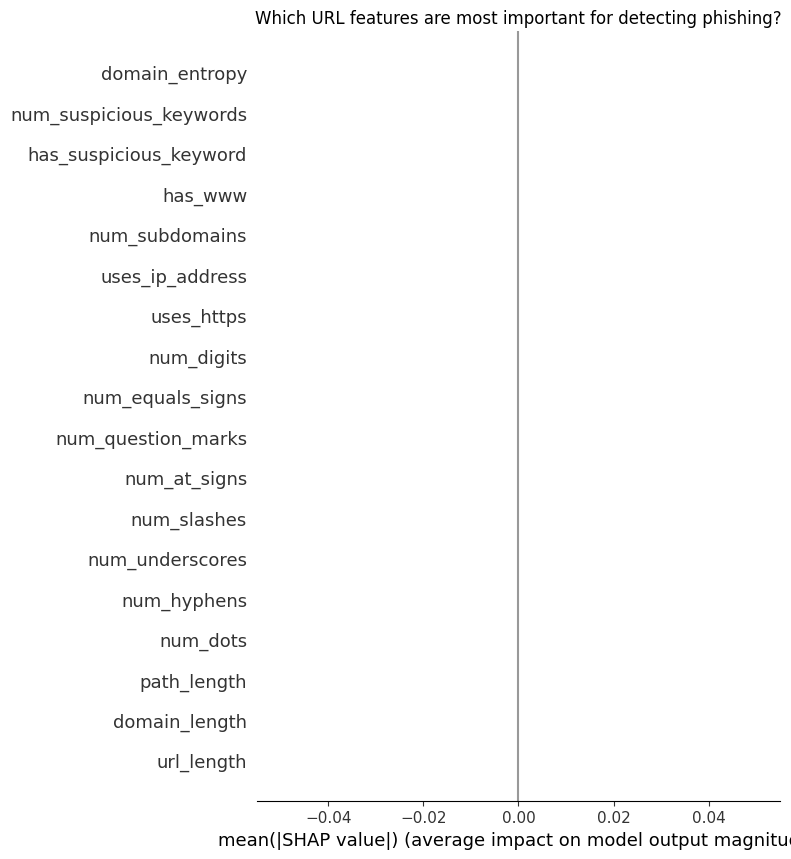

Saved to docs/screenshots/shap_global_importance.png


In [3]:
os.makedirs('../docs/screenshots', exist_ok=True)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("Which URL features are most important for detecting phishing?")
plt.tight_layout()
plt.savefig('../docs/screenshots/shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to docs/screenshots/shap_global_importance.png")

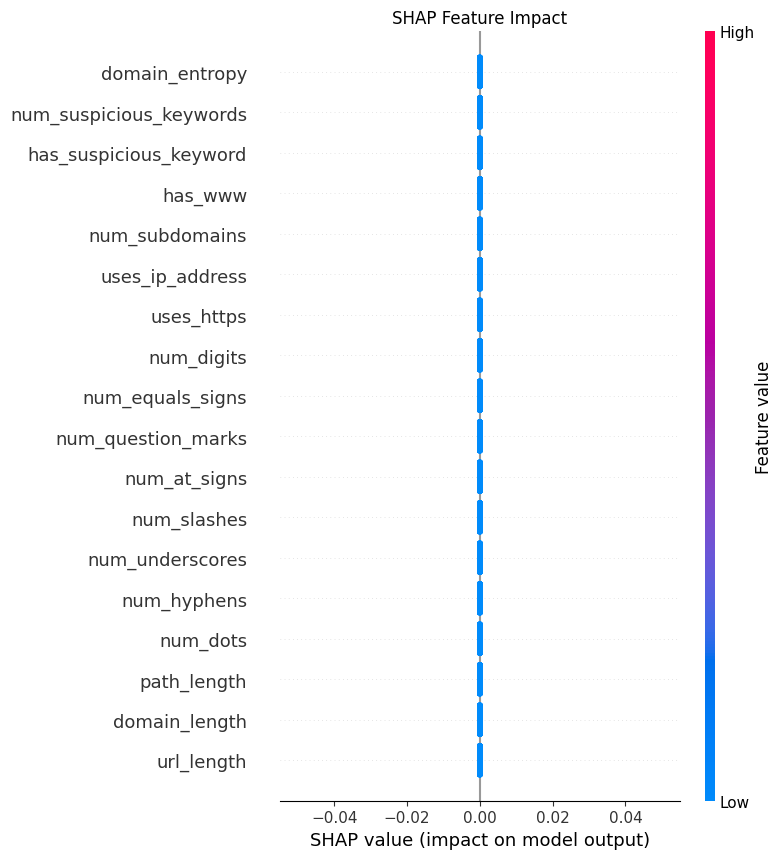

In [4]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Feature Impact")
plt.tight_layout()
plt.savefig('../docs/screenshots/shap_dot_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
sample_index = 5
single_X = X_sample.iloc[sample_index:sample_index+1]
single_shap = shap_values[sample_index]

prediction = model.predict(single_X)[0]
confidence = model.predict_proba(single_X)[0][1]

print(f"=== Local Explanation for Sample #{sample_index} ===")
print(f"Predicted: {'Phishing' if prediction == 1 else 'Legitimate'}")
print(f"Phishing confidence: {confidence:.3f}")
print()

contributions = list(zip(X_sample.columns, single_X.values[0], single_shap))
contributions.sort(key=lambda x: abs(x[2]), reverse=True)

for feature_name, feature_value, shap_val in contributions:
    direction = "→ PHISHING" if shap_val > 0 else "→ legitimate"
    print(f"  {feature_name:35s} = {feature_value:8.2f} | {shap_val:+.4f} {direction}")

=== Local Explanation for Sample #5 ===
Predicted: Phishing
Phishing confidence: 0.572

  url_length                          =     0.00 | +0.0000 → legitimate
  domain_length                       =     0.00 | +0.0000 → legitimate
  path_length                         =     0.00 | +0.0000 → legitimate
  num_dots                            =     0.00 | +0.0000 → legitimate
  num_hyphens                         =     0.00 | +0.0000 → legitimate
  num_underscores                     =     0.00 | +0.0000 → legitimate
  num_slashes                         =     0.00 | +0.0000 → legitimate
  num_at_signs                        =     0.00 | +0.0000 → legitimate
  num_question_marks                  =     0.00 | +0.0000 → legitimate
  num_equals_signs                    =     0.00 | +0.0000 → legitimate
  num_digits                          =     0.00 | +0.0000 → legitimate
  uses_https                          =     0.00 | +0.0000 → legitimate
  uses_ip_address                     =     0.00

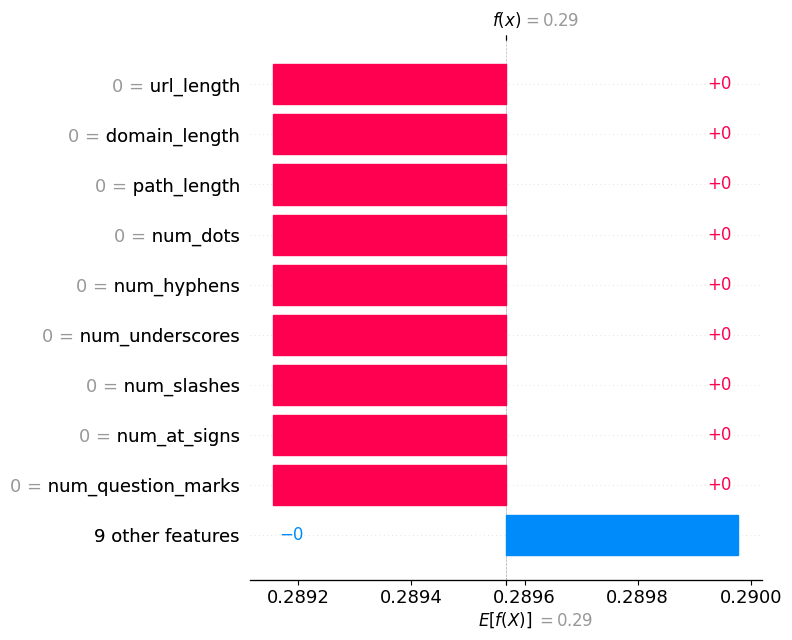

Saved to docs/screenshots/shap_waterfall_example.png


In [6]:
shap_explanation = shap.Explanation(
    values=shap_values[sample_index],
    base_values=explainer.expected_value,
    data=X_sample.iloc[sample_index].values,
    feature_names=X_sample.columns.tolist()
)

plt.figure()
shap.waterfall_plot(shap_explanation, show=False)
plt.tight_layout()
plt.savefig('../docs/screenshots/shap_waterfall_example.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to docs/screenshots/shap_waterfall_example.png")